# Kanawha River — Terrain and Floodplain Analysis   

This notebook explores the terrain and floodplain of the **Kanawha River** (West Virginia, USA) using Sage natural-language cells. Each cell asks a question in plain English; Sage fetches data, runs the analysis, and renders the result inline.                              

**What it does, step by step:**                                                                                                                                          
  1. Find the main channel of the Kanawha River from the NHD flowline network.                                                                                             
  2. Check 3DEP DEM resolutions available for the river's bounding box.                                                                                                    
  3. Download a 30 m DEM and overlay the main channel.                                                                                                                     
  4. Sample the longitudinal elevation profile along the channel.                                                                                                          
  5. Show the reaches of the Kanawha River.                                                                                                                                
  6. Compute a Relative Elevation Model (REM) for a clipped reach and visualize it with a dark hillshade + inferno colormap.                                               
                                                                                                                                                                           
**Data sources:** USGS NHD (flowlines, reaches), USGS 3DEP (DEMs), USGS seamless 10 m DEM VRT (elevation sampling).         

In [ ]:
%reset

In [2]:
%%skill
https://github.com/klinucsd/sage_skills/tree/main/hydrography/nhd-rivers
https://github.com/klinucsd/sage_skills/tree/main/topography/py3dep-dem
https://github.com/klinucsd/sage_skills/tree/main/hydrography/kanawha-reach-impact

In [3]:
%%ask
Find the main channel of the Kanawha River

I'll consult the relevant skills for river/hydrography data and the Kanawha-specific skill.

Now I'll write a script using the nhd-rivers skill to fetch NHD flowlines and extract the Kanawha River main channel.

Running the script to fetch NHD flowlines and extract the Kanawha River main channel.

The script succeeded. Now let me create a colormap for the main channel map layer.

Here are the results:

## Kanawha River Main Channel

The main channel of the Kanawha River was extracted from the National Hydrography Dataset (NHD) using `pynhd`.

**Key facts:**

| Attribute | Value |
|-----------|-------|
| **Segments** | 108 NHD flowline segments |
| **Approximate length** | 177.6 km (≈110 mi) |
| **Strahler stream order** | 6 |
| **CRS** | EPSG:4326 (WGS 84) |
| **Data source** | USGS NHD flowline network |

The river flows from its headwaters (hydroseq 430001187) westward to its outlet at the Ohio River near Point Pleasant, WV (hydroseq 430000838).

In [4]:
%%ask           
Check what 3DEP DEM resolutions are available for the Kanawha River.

Let me first consult the py3dep-dem skill for the proper approach to checking DEM availability.

Now I'll check what files exist in the working directory and look for the Kanawha River GeoJSON to get its bounding box.

Writing the availability check script following the skill's Example 2 pattern.

Running the availability check script.

## 3DEP DEM Availability for the Kanawha River

**All three standard resolutions are available** across the full extent of the Kanawha River main channel:

| Resolution | Status | Notes |
|------------|--------|-------|
| **1 m** | ✓ Available | LiDAR-derived — best detail |
| **3 m** | ✓ Available | Intermediate LiDAR product |
| **10 m** | ✓ Available | Standard USGS quad DEM |
| **30 m** | ✓ Available | National Elevation Dataset |
| 5 m | ✗ Not available | — |
| 60 m | ✗ Not available | — |
| topobathy | ✗ Not available | — |

**Kanawha River bounding box** (EPSG:4326):
- **West** : −82.14° / **East** : −81.20°
- **South** : 38.12° / **North** : 38.84°
- **Extent** : 0.95° × 0.72° (roughly 80 km × 80 km)

The 1 m LiDAR-derived DEM is the best choice for detailed floodplain or channel morphology analysis, while 10 m is a good balance of speed and detail for reach-scale work. The 30 m product covers the entire corridor with minimal download time.

Let me check the existing kernel variables and the river GeoJSON structure.

Now I have the river GeoJSON and the skill instructions. The Kanawha River spans approximately 0.95° longitude — too large for a single DEM download. Per the skill's guidance, I'll use `get_dem_bbox()` to get a manageable 0.1° × 0.1° bbox, download the 30 m DEM, and overlay the river in red using the skill's `plot_river_on_dem()` function.

Writing the script using the skill's `get_dem` and `plot_river_on_dem` functions.

Running the script to download the 30 m DEM and generate the overlay map.

The DEM downloaded successfully and the overlay plot was generated. Let me update the todos and report.

## 30 m DEM — Kanawha River Main Channel

The 30-meter USGS 3DEP DEM was downloaded for the full extent of the Kanawha River and the main channel is overlaid in red.

| Attribute | Value |
|-----------|-------|
| **Resolution** | 30 m |
| **DEM CRS** | EPSG:5070 (NAD83 / Conus Albers) |
| **Grid size** | 3,415 × 3,461 pixels |
| **Elevation range** | 158–848 m |
| **River segments** | 108 NHD flowlines |
| **River CRS** | EPSG:4326 (reprojected to DEM CRS for overlay) |

The DEM shows the Kanawha River valley floor (≈160–170 m elevation at Point Pleasant) rising through the Appalachian Plateau to the east (≈840 m near the headwaters). The river flows westward (right to left on the map) from the Gauley Bridge area to its confluence with the Ohio River.


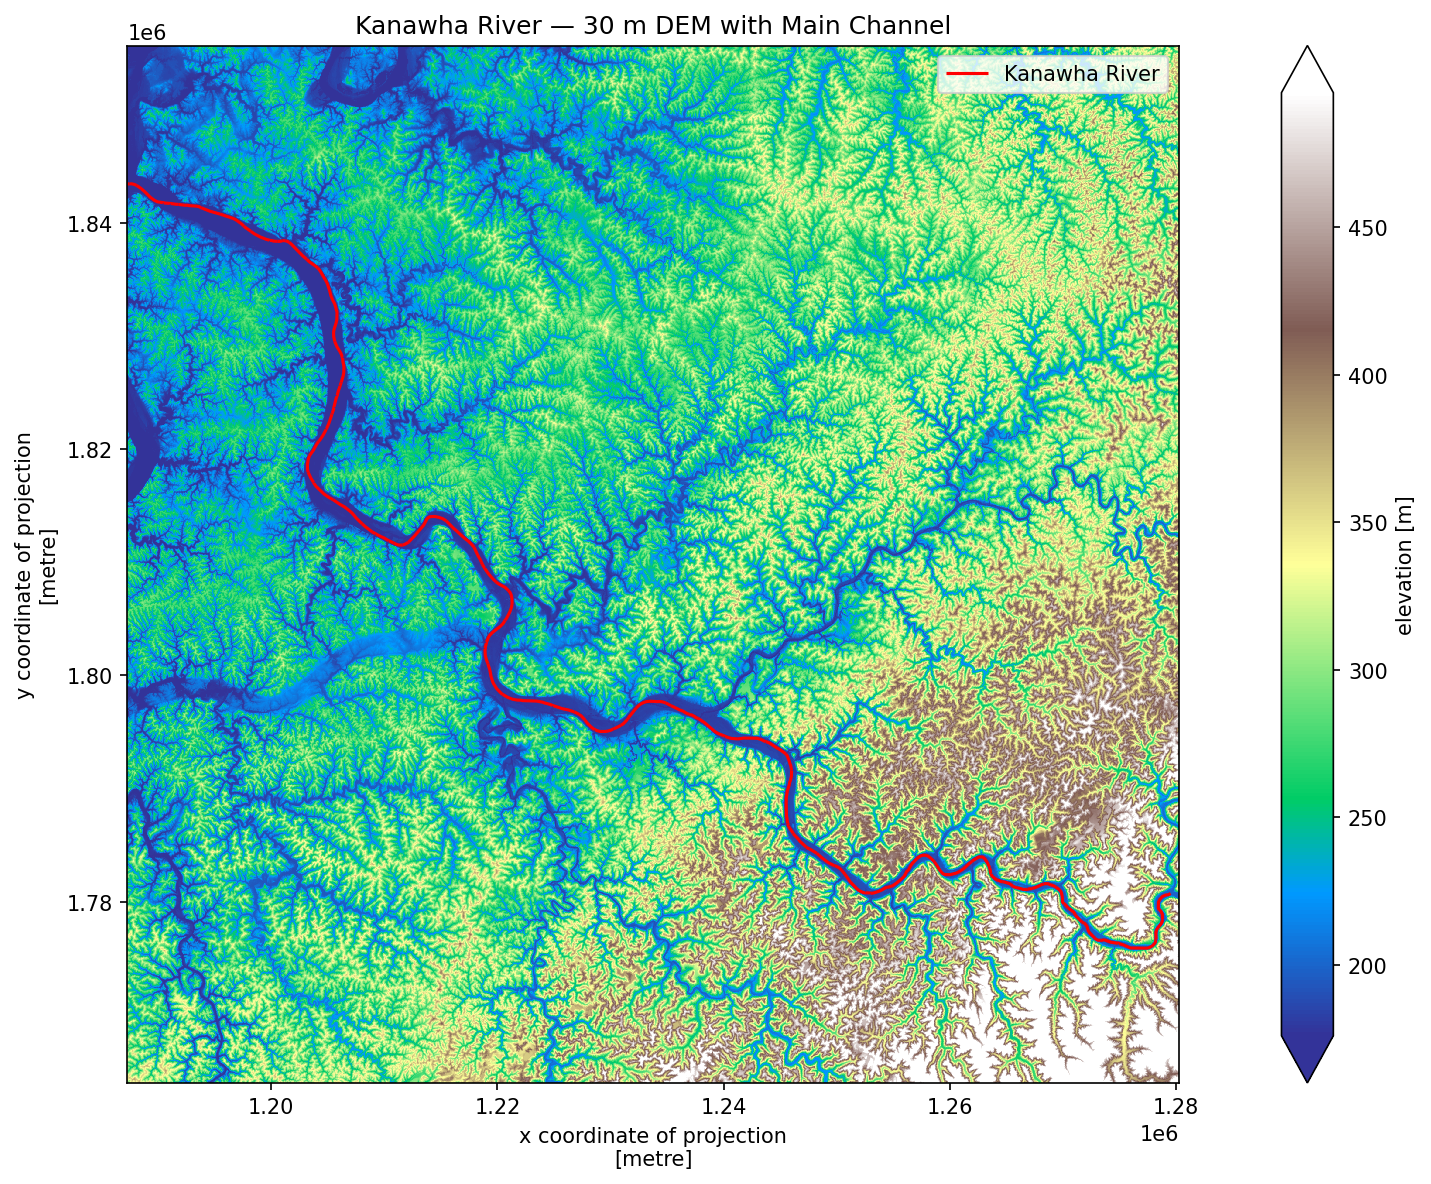

In [5]:
%%ask           
Download a 30-meter DEM for the Kanawha River main channel. 
Show the river in red on the DEM. 

Let me check the working directory for existing files and consult relevant skills.

Now I'll write the elevation profile script using the skill's Example 4 verbatim, filling in the four variables for the Kanawha River.

Running the elevation profile script.

The script completed successfully. Here's the result:

## Kanawha River — Longitudinal Elevation Profile

| Attribute | Value |
|-----------|-------|
| **Sample points** | 3,553 (50 m spacing) |
| **Elevation range** | 164–199 m |
| **River length** | 155.2 km |
| **Total relief** | ~35 m |

The profile shows a gentle downstream gradient from ~199 m at the headwaters (Gauley Bridge area) to ~164 m at the Ohio River confluence near Point Pleasant, giving an average slope of roughly 0.02% — characteristic of a mature, low-gradient Appalachian river.


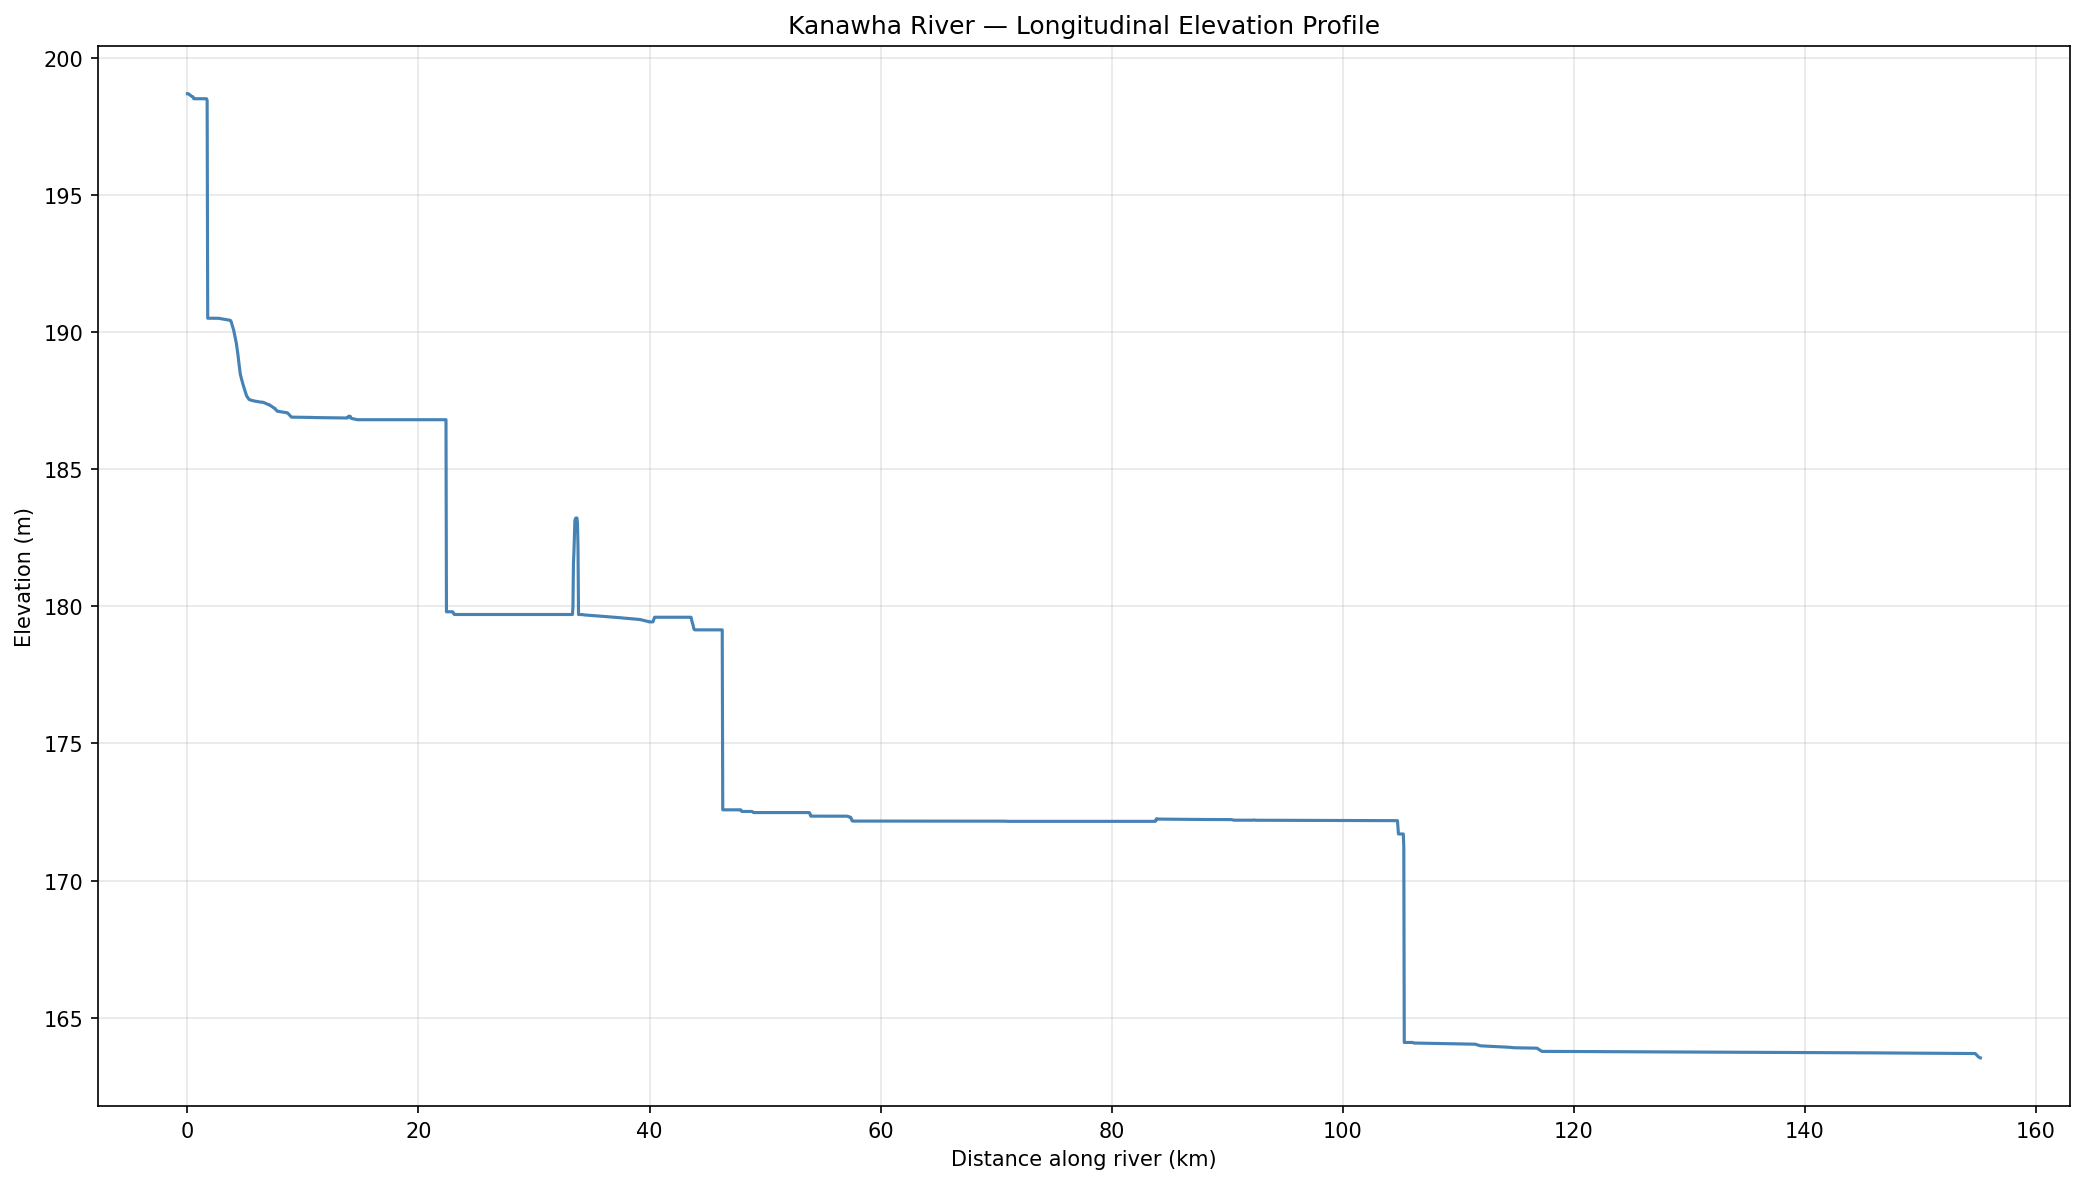

In [6]:
%%ask                                                                                                                                                                    
Sample the elevation profile along the Kanawha River and plot distance vs elevation,
with the y-axis showing only the actual elevation range.

In [7]:
%%ask
Show the reaches of the Kanawha River

Let me consult the relevant skills for NHD river reaches and Kanawha-specific workflows.

Now let me check what files already exist in the working directory and look for existing data.

The kanawha-reach-impact skill shows reach polygons available from GeoServer. I'll fetch those reaches and display them on the map.

Running the script to fetch the reach polygons from GeoServer.

All 13 reach polygons fetched successfully. Let me verify the colormap looks right.

I notice reach4a and reach4d share the same color — let me fix that for distinctness.

## Kanawha River Reaches

All **13 reach polygons** were fetched from the USACE GeoServer and are displayed below. Each reach is a buffer zone along the Kanawha River tied to a specific USGS gauge station.

| Reach | Gauge | USGS ID | Approx. Area |
|-------|-------|---------|-------------|
| reach1 | POPW2 | 03201500 | ~1,619 km² |
| reach2 | POPW2&CRSW2 | — | ~965 km² |
| reach3 | POPW2&CRSW2 | — | ~2,447 km² |
| reach4 | CRSW2 | — | ~793 km² |
| reach4a | QUSW2 | 03197000 | ~793 km² |
| reach4b | CLYW2 | 03196800 | ~533 km² |
| reach4c | FRMW2 | 03196600 | ~303 km² |
| reach4d | USGS03195500 | 03195500 | ~196 km² |
| reach5 | KANW2 | 03193000 | ~1,187 km² |
| reach6 | HINW2 | 03184500 | ~953 km² |
| reach6a | BVAW2 | 03192000 | ~285 km² |
| reach6b | USGS03189600 | 03189600 | ~309 km² |
| reach7 | ALDW2 | 03183500 | ~409 km² |

The numbering follows the river downstream: **reach7** (upstream, Alderson area) → ** reach1** (downstream, Point Pleasant at the Ohio River confluence). Sub-reaches (4a–4d, 6a–6b) break the middle corridor into finer segments around Charleston and tributary junctions.

Let me start by consulting the relevant skills for DEM processing and REM computation.

Now let me read the existing data files to understand the structure.

Now I have the skill's REM workflow. Let me write a script that clips the main channel to reach5, downloads the DEM for that bbox, computes the REM, and visualizes it.

Writing the full REM pipeline script following the skill's exact patterns.

Running the full REM pipeline script.

All steps completed successfully. Let me update the todo list.

## Relative Elevation Model — Kanawha River Reach 5

The reach5 segment was clipped from the full main channel and a 30 m REM was computed using IDW interpolation of the river thalweg elevation.

| Attribute | Value |
|-----------|-------|
| **Reach** | reach5 (gauge KANW2, USGS 03193000) |
| **Clipped segments** | 32 NHD flowlines |
| **River length** | 42.1 km |
| **DEM grid** | 781 × 1,287 pixels (30 m resolution) |
| **DEM CRS** | EPSG:5070 (NAD83 / Conus Albers) |
| **Elevation range** | 172–749 m |
| **River thalweg** | 179–190 m |
| **REM range** | 0.0–562.2 m above thalweg |
| **Bbox** | −81.57° to −81.21° W, 38.12° to 38.26° N |

The REM shows the floodplain terraces and valley walls rising above the channel — dark tones near the river (low relative elevation) and bright tones on the surrounding hillslopes.


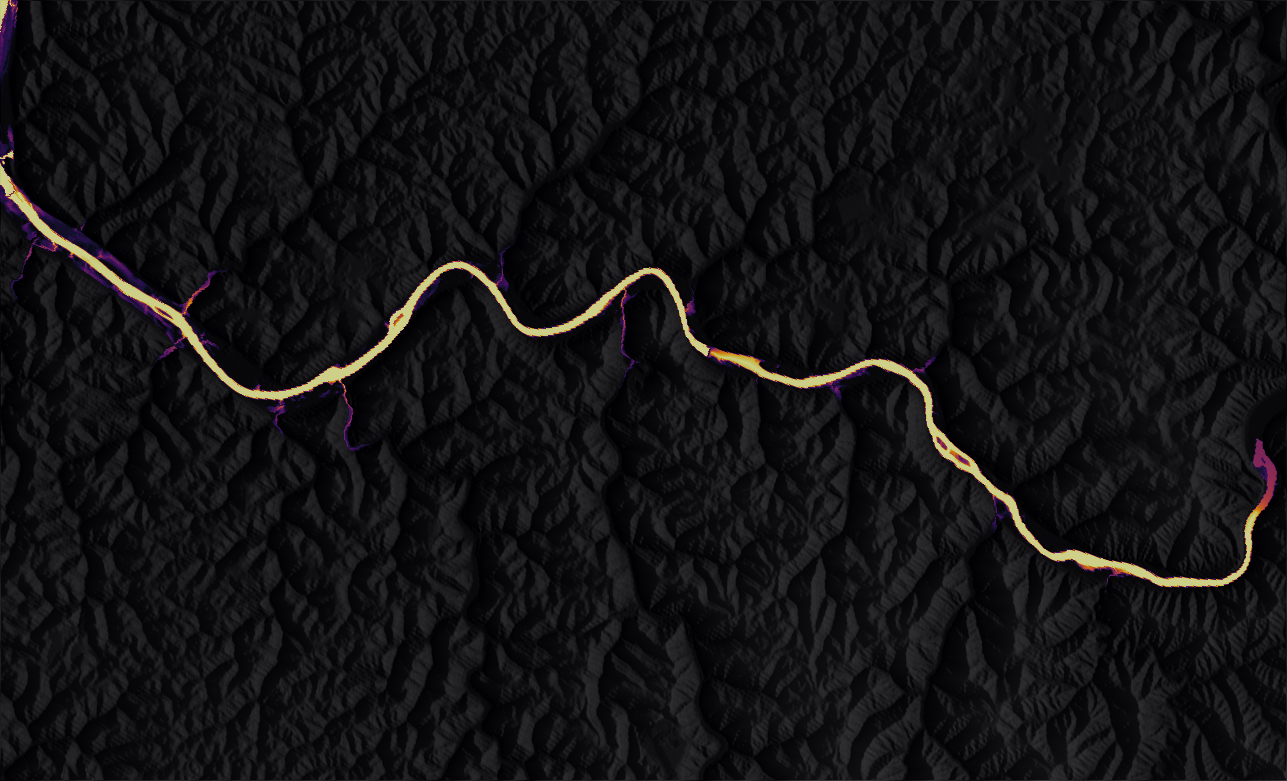

In [8]:
%%ask                                                                                                                                                                    
Clip the Kanawha River segment in the reach5 and compute a Relative Elevation Model (REM) 
for the bounding box of the segment using 30-meter DEM. 
Show the REM visualization using datashader with hillshade + inferno.